In [6]:
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from census import Census
from us import states
from ipumspy import (
    IpumsApiClient,
    AggregateDataExtract,
    NhgisDataset,
)
BASE = "/Users/samstephenson/Downloads/capy-bara"
os.chdir(BASE)


In [7]:

CENSUS_KEY = "7e1b79ce2adac634987a423b6d7fb99510fee50e"


In [9]:
FIPS = "17,18,55"

In [8]:
census_2020 = Census(
    key=CENSUS_KEY,      # We use the provided Census API key.
    year=2020    # We specify that we would like to use the 2020 Census data.
)

In [11]:
p1_population_columns_2020 = {
    "P1_003N": "WHITE",         # White alone
    "P1_004N": "BLACK",         # Black or African American alone
    "P1_005N": "AMIN",          # American Indian and Alaska Native alone
    "P1_006N": "ASIAN",         # Asian alone
    "P1_007N": "NHPI",          # Native Hawaiian and Other Pacific Islander alone
    "P1_008N": "OTHER",     # Some Other Race alone
    "P1_009N": "2MORE",     # Two or more races
    "P1_001N" : "TOTPOP"  #Total Population        
}

df_tracts_2020 = census_2020.pl.get(
    ("NAME", *p1_population_columns_2020),
    geo={
        "for": "place:*",
        "in": f"state:{FIPS}",
    }, 
)

df_tracts_2020 = pd.DataFrame(df_tracts_2020).rename(
    columns={"NAME": "name", **p1_population_columns_2020}
)

In [59]:
places = gpd.read_file("/Users/samstephenson/Downloads/capy-bara/Place/nhgis0084_shapefile_tl1992_us_place_1980/US_place_1980.shp").to_crs("esri:102003")

In [60]:
city = gpd.read_file("study_areas/definitions/cbsa_10180_march_2020.shp").to_crs("esri:102003")

In [67]:
place = places[places.intersects(city.union_all())]


In [62]:
city

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,...,INTPTLAT,INTPTLON,JOIN_KEY,GISJOIN,WHITE,BLACK,TOTPOP,POC,STCNTYFP,geometry
0,48,253,01383912,48253,Jones,Jones County,06,H1,G4020,None,...,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253,"POLYGON ((-317094.355 -551925.31, -316435.868 ..."


In [68]:
place

,STATE80,PL80,NAME,GISJOIN,GISJOIN2,geometry
18754,48,0015,Abilene,G4800015,4800015,"MULTIPOLYGON (((-343846.805 -562853.763, -3438..."
18787,48,0140,Anson,G4800140,4800140,"POLYGON ((-362457.914 -521904.898, -362460.268..."
18811,48,0245,Baird,G4800245,4800245,"POLYGON ((-316615.432 -563798.56, -316619.799 ..."
18901,48,0635,Buffalo Gap,G4800635,4800635,"MULTIPOLYGON (((-359168.445 -574993.239, -3584..."
18963,48,0885,Clyde,G4800885,4800885,"POLYGON ((-328979.963 -562510.198, -328881.538..."
19003,48,1035,Cross Plains,G4801035,4801035,"POLYGON ((-296759.227 -594730.562, -296765.943..."
19192,48,1810,Hamlin,G4801810,4801810,"POLYGON ((-383517.947 -505943.845, -383467.625..."
19202,48,1843,Hawley,G4801843,4801843,"POLYGON ((-355195.396 -538554.632, -355117.552..."
19252,48,2033,Impact,G4802033,4802033,"POLYGON ((-349871.46 -552151.598, -349872.778 ..."
19347,48,2410,Lawn,G4802410,4802410,"POLYGON ((-351610.952 -592240.01, -351540.562 ..."


<Axes: >

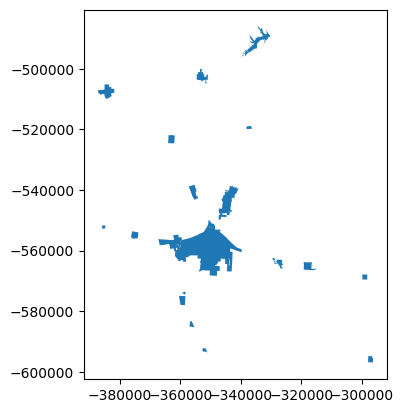

In [64]:
place.sort_values(by = "TOTPOP", ascending = False, inplace = True)    
place
    

,STATE80,PL80,NAME_left,GISJOIN_left,GISJOIN2,geometry,STATEFP,COUNTYFP,COUNTYNS,GEOID,...,AWATER,INTPTLAT,INTPTLON,JOIN_KEY,GISJOIN_right,WHITE,BLACK,TOTPOP,POC,STCNTYFP
18754,48,0015,Abilene,G4800015,4800015,"MULTIPOLYGON (((-343846.805 -562853.763, -3438...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253
19347,48,2410,Lawn,G4802410,4802410,"POLYGON ((-351610.952 -592240.01, -351540.562 ...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253
19824,48,4340,Tuscola,G4804340,4804340,"POLYGON ((-355407.767 -585124.777, -355395.004...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253
19816,48,4305,Trent,G4804305,4804305,"POLYGON ((-384953.52 -551709.1, -384948.393 -5...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253
19757,48,4065,Stamford,G4804065,4804065,"MULTIPOLYGON (((-352951.641 -501000.473, -3529...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253
19605,48,3425,Putnam,G4803425,4803425,"POLYGON ((-298264.083 -568601.531, -298288.098...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253
19434,48,2775,Merkel,G4802775,4802775,"POLYGON ((-374050.651 -555731.602, -374103.446...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253
19390,48,2570,Lueders,G4802570,4802570,"POLYGON ((-336452.061 -519006.896, -336460.231...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253
19252,48,2033,Impact,G4802033,4802033,"POLYGON ((-349871.46 -552151.598, -349872.778 ...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253
18787,48,0140,Anson,G4800140,4800140,"POLYGON ((-362457.914 -521904.898, -362460.268...",48,253,01383912,48253,...,22097342,+32.7437089,-099.8744297,48253,G48253,11485,1978,19663,8178,48253


In [65]:
output_dir = '/Users/samstephenson/Desktop/untitled folder'
place.to_file(os.path.join(output_dir, 'place.shp'))
city.to_file(os.path.join(output_dir, 'city.shp'))

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_13236/2080187878.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  place.to_file(os.path.join(output_dir, 'place.shp'))
/Users/samstephenson/venvs/py314/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'GISJOIN_left' to 'GISJOIN_le'
  ogr_write(
/Users/samstephenson/venvs/py314/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'GISJOIN_right' to 'GISJOIN_ri'
  ogr_write(
